In [96]:
import pandas as pd

In [97]:
df = pd.read_excel("Dados/Dados_abertos_Consumo_Mensal-.xlsx")
print(df.shape)
df.head()

(16894, 8)


,Data,DataExcel,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores
0,20240901,2024-09-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Cativo,440778.355,501914.0
1,20240901,2024-09-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Livre,202637.066,2362.0
2,20240901,2024-09-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Cativo,88018.441,31043.0
3,20240901,2024-09-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,889059.013,994.0
4,20240901,2024-09-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Outros,Cativo,363105.975,63157.0


In [98]:
# group df bt Data + Regiao
new_df = df[['DataExcel', 'Regiao', 'Consumo']].groupby(['DataExcel', 'Regiao']).sum().reset_index()
new_df = new_df.rename(columns={'DataExcel': 'Data'})
print(new_df.shape)
new_df.head()

(1245, 3)


,Data,Regiao,Consumo
0,2004-01-01,Centro-Oeste,1.507174e+06
1,2004-01-01,Nordeste,4.457112e+06
2,2004-01-01,Norte,1.574434e+06
3,2004-01-01,Sudeste,1.492953e+07
4,2004-01-01,Sul,4.510113e+06


In [99]:
new_df['Regiao'].value_counts()

Regiao
Centro-Oeste    249
Nordeste        249
Norte           249
Sudeste         249
Sul             249
Name: count, dtype: int64

In [100]:
new_df['Consumo'].iloc[0:10]

0    1.507174e+06
1    4.457112e+06
2    1.574434e+06
3    1.492953e+07
4    4.510113e+06
5    1.456013e+06
6    4.139867e+06
7    1.507449e+06
8    1.471471e+07
9    4.690228e+06
Name: Consumo, dtype: float64

In [101]:
# format e number into a human readable format
new_df['Consumo'].apply(lambda x: '{:,.2f}'.format(x)).iloc[0:10]

0     1,507,173.82
1     4,457,112.27
2     1,574,434.32
3    14,929,528.08
4     4,510,112.99
5     1,456,012.78
6     4,139,867.00
7     1,507,448.57
8    14,714,713.10
9     4,690,227.85
Name: Consumo, dtype: object

In [102]:
# group dataset by year-month (Data is formatted as YYYY-MM-DD, we need to extract year and month)
test_new_df = new_df.copy()

test_new_df['Year-Month'] = test_new_df['Data'].dt.to_period('M')

# group by year-month and sum the consumption
test_new_df = test_new_df.groupby('Year-Month')['Consumo'].sum().reset_index()

# make it human readable again
test_new_df['Consumo_readable'] = test_new_df['Consumo'].apply(lambda x: '{:,.2f}'.format(x))

# transform by e^3
test_new_df['Consumo_GWh'] = test_new_df['Consumo'] / 1e3

# consumo TWh
test_new_df['Consumo_TWh'] = test_new_df['Consumo'] / 1e6

# sum all consumo by years
consumo_by_year = test_new_df.groupby(test_new_df['Year-Month'].dt.year)['Consumo'].sum().reset_index()

consumo_by_year['Consumo_GWh'] = consumo_by_year['Consumo'] / 1e3
consumo_by_year['Consumo_TWh'] = consumo_by_year['Consumo'] / 1e6
consumo_by_year['Consumo_readable'] = consumo_by_year['Consumo'].apply(lambda x: '{:,.2f}'.format(x))

display(consumo_by_year)

display(test_new_df.head())

,Year-Month,Consumo,Consumo_GWh,Consumo_TWh,Consumo_readable
0,2004,3.318689e+08,331868.930857,331.868931,"331,868,930.86"
1,2005,3.453313e+08,345331.272218,345.331272,"345,331,272.22"
2,2006,3.561293e+08,356129.310247,356.129310,"356,129,310.25"
3,2007,3.770311e+08,377031.054000,377.031054,"377,031,054.00"
4,2008,3.884724e+08,388472.398890,388.472399,"388,472,398.89"
5,2009,3.843064e+08,384306.380350,384.306380,"384,306,380.35"
6,2010,4.156678e+08,415667.757665,415.667758,"415,667,757.67"
7,2011,4.330156e+08,433015.633857,433.015634,"433,015,633.86"
8,2012,4.481264e+08,448126.390777,448.126391,"448,126,390.78"
9,2013,4.631383e+08,463138.257625,463.138258,"463,138,257.62"


,Year-Month,Consumo,Consumo_readable,Consumo_GWh,Consumo_TWh
0,2004-01,2.697836e+07,"26,978,361.46",26978.361463,26.978361
1,2004-02,2.650827e+07,"26,508,269.30",26508.269295,26.508269
2,2004-03,2.728434e+07,"27,284,337.17",27284.337172,27.284337
3,2004-04,2.804618e+07,"28,046,181.32",28046.181323,28.046181
4,2004-05,2.724816e+07,"27,248,156.75",27248.156753,27.248157


In [103]:
consumo_by_year.iloc[:5].to_json()

'{"Year-Month":{"0":2004,"1":2005,"2":2006,"3":2007,"4":2008},"Consumo":{"0":331868930.8569999933,"1":345331272.2179999948,"2":356129310.246999979,"3":377031054.0,"4":388472398.8899999857},"Consumo_GWh":{"0":331868.930857,"1":345331.272218,"2":356129.310247,"3":377031.054,"4":388472.39889},"Consumo_TWh":{"0":331.868930857,"1":345.331272218,"2":356.129310247,"3":377.031054,"4":388.47239889},"Consumo_readable":{"0":"331,868,930.86","1":"345,331,272.22","2":"356,129,310.25","3":"377,031,054.00","4":"388,472,398.89"}}'

In [104]:
df2 = pd.read_csv("Dados/bandeira-tarifaria-acionamento.csv", sep=';', encoding='latin1')
print(df2.shape)
df2.head()

(135, 4)


,DatGeracaoConjuntoDados,DatCompetencia,NomBandeiraAcionada,VlrAdicionalBandeira
0,2026-03-16,2015-01-01,Vermelha P1,"30,00"
1,2026-03-16,2015-02-01,Vermelha P1,"30,00"
2,2026-03-16,2015-03-01,Vermelha P1,"55,00"
3,2026-03-16,2015-04-01,Vermelha P1,"55,00"
4,2026-03-16,2015-05-01,Vermelha P1,"55,00"


In [105]:
df2['NomBandeiraAcionada'].value_counts()

NomBandeiraAcionada
Verde               66
Vermelha P1         26
Amarela             20
Vermelha P2         15
Escassez Hídrica     8
Name: count, dtype: int64

In [106]:
df2 = df2[df2['DatCompetencia'] <= '2024-09-01']

In [107]:
"""
Consumo de energia elétrica x Bandeiras Tarifárias — Brasil
Tufte-style: small multiples (Total + 5 regiões), faixas de bandeira a partir de 2015.

Para usar com seus dados reais, substitua as seções marcadas com # ── SEUS DADOS ──
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Paleta Tufte
# ─────────────────────────────────────────────────────────────────────────────
BG         = "#fffff8"
TEXT       = "#111111"
TEXT_SEC   = "#666666"
AXIS_C     = "#cccccc"
SERIF      = ["DejaVu Serif", "serif"]
SANS       = ["DejaVu Sans", "sans-serif"]

# Cores das bandeiras (inspiradas nas cores reais da ANEEL)
BANDEIRA_CORES = {
    "Verde":        ("#2d6a4f", 0.12),
    "Amarela":      ("#b5830a", 0.15),
    "Vermelha P1":  ("#c0392b", 0.15),
    "Vermelha P2":  ("#7b0f0f", 0.18),
    "Escassez Hídrica":     ("#4a0000", 0.20),
}
# Fallback para bandeiras não mapeadas
BANDEIRA_DEFAULT = ("#888888", 0.10)

consumo = new_df.copy()
bandeiras = df2.copy()

In [108]:
# consumo date range
print("Consumo: ", consumo["Data"].min(), "até", consumo["Data"].max())
# bandeiras date range
print("Bandeiras: ", bandeiras["DatCompetencia"].min(), "até", bandeiras["DatCompetencia"].max())

Consumo:  2004-01-01 00:00:00 até 2024-09-01 00:00:00
Bandeiras:  2015-01-01 até 2024-09-01


In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# Pré-processamento
# ─────────────────────────────────────────────────────────────────────────────
consumo["Data"] = pd.to_datetime(consumo["Data"].astype(str), format="%Y-%m-%d")
consumo["YM"]   = consumo["Data"].dt.to_period("M")

bandeiras["DatCompetencia"] = pd.to_datetime(bandeiras["DatCompetencia"])
bandeiras["YM"] = bandeiras["DatCompetencia"].dt.to_period("M")
bandeiras = bandeiras.drop_duplicates("YM").sort_values("YM")

# Total Brasil
total = consumo.groupby("YM")["Consumo"].sum().reset_index()
total["Regiao"] = "Brasil (total)"

# Série por região
por_regiao = consumo.groupby(["YM", "Regiao"])["Consumo"].sum().reset_index()

In [110]:
# ─────────────────────────────────────────────────────────────────────────────
# Helpers de plotagem
# ─────────────────────────────────────────────────────────────────────────────
def limpar_eixos(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(AXIS_C)
    ax.spines["bottom"].set_color(AXIS_C)
    ax.set_facecolor(BG)
    ax.grid(False)
    ax.tick_params(colors=TEXT_SEC, length=3, width=0.5)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(SANS)
        lbl.set_fontsize(8)


def range_frame(ax, xmin, xmax, ymin, ymax, padx=0.01, pady=0.03):
    # For datetime x-axis, set_bounds expects numeric (date2num) values
    xmin_n = mdates.date2num(xmin)
    xmax_n = mdates.date2num(xmax)
    xpad = (xmax_n - xmin_n) * padx
    ypad = (ymax - ymin) * pady
    ax.spines["bottom"].set_bounds(xmin_n - xpad, xmax_n + xpad)
    ax.spines["left"].set_bounds(ymin - ypad, ymax + ypad)


def pintar_bandeiras(ax, bandeiras_df, xmin_num, xmax_num):
    """Pinta faixas verticais coloridas para cada período de bandeira."""
    df = bandeiras_df.sort_values("YM").reset_index(drop=True)
    for i, row in df.iterrows():
        t_inicio = row["DatCompetencia"]
        t_fim    = (df.loc[i + 1, "DatCompetencia"]
                    if i + 1 < len(df)
                    else t_inicio + pd.DateOffset(months=1))
        nome = row["NomBandeiraAcionada"]

        # Normaliza variações como "Vermelha Patamar 1" → "Vermelha P1"
        nome_norm = nome
        for key in BANDEIRA_CORES:
            if key.lower() in nome.lower():
                nome_norm = key
                break

        cor, alpha = BANDEIRA_CORES.get(nome_norm, BANDEIRA_DEFAULT)
        x0 = max(t_inicio.timestamp(), xmin_num)
        x1 = min(t_fim.timestamp(),    xmax_num)
        if x1 > x0:
            ax.axvspan(t_inicio, t_fim, color=cor, alpha=alpha, lw=0)


def rotulo_direto(ax, serie_x, serie_y, texto, cor, fontsize=8):
    """Rótulo direto no último ponto da série."""
    ax.text(serie_x.iloc[-1], serie_y.iloc[-1], f"  {texto}",
            fontfamily=SERIF, fontsize=fontsize, color=cor,
            va="center", clip_on=False)

Salvo: visualizacao_bandeiras.png


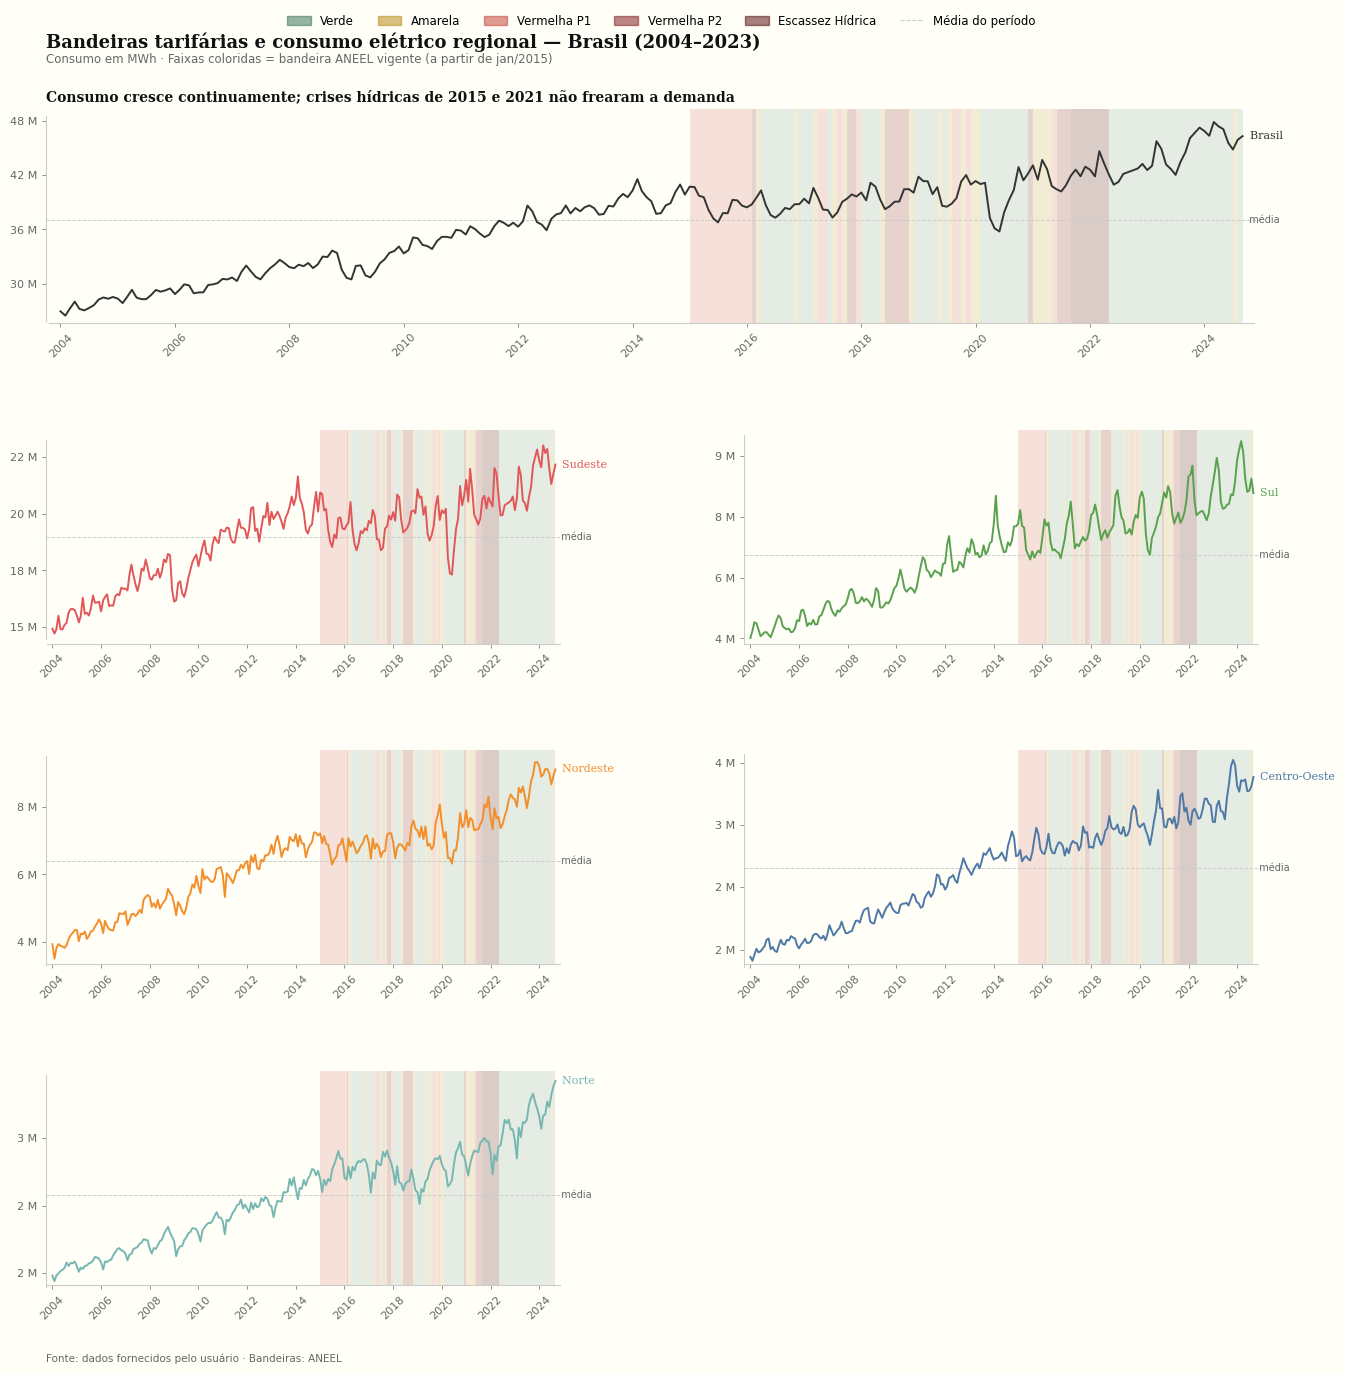

In [111]:


# ─────────────────────────────────────────────────────────────────────────────
# Layout: 1 total (topo) + 5 regiões (2 cols x 3 linhas)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 14), facecolor=BG)
fig.patch.set_facecolor(BG)

gs = fig.add_gridspec(
    4, 2,
    hspace=0.50, wspace=0.35,
    top=0.91, bottom=0.07, left=0.07, right=0.88,
)

# Painel total ocupa linha inteira no topo
ax_total = fig.add_subplot(gs[0, :])

# 5 regiões em linhas 1-2 (2 colunas cada)
axes_reg = [
    fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]),
    fig.add_subplot(gs[3, 0]),  # Norte sozinho na linha 3
]

# Cor por região
CORES_REG = {
    "Centro-Oeste": "#4e79a7",
    "Nordeste":     "#f28e2b",
    "Norte":        "#76b7b2",
    "Sudeste":      "#e15759",
    "Sul":          "#59a14f",
}

# ─────────────────────────────────────────────────────────────────────────────
# Função genérica de painel
# ─────────────────────────────────────────────────────────────────────────────
def plotar_painel(ax, serie_df, col_x, col_y, titulo, cor_linha,
                  bandeiras_df, ylabel="MWh", show_xlabel=False,
                  rotulo=None, milhoes=False):

    xs = pd.to_datetime(serie_df[col_x].dt.to_timestamp())
    ys = serie_df[col_y]
    if milhoes:
        ys = ys / 1e6

    # Faixas de bandeira (apenas a partir de 2015)
    xmin_dt = xs.min()
    xmax_dt = xs.max()
    bf_filtrado = bandeiras_df[bandeiras_df["DatCompetencia"] >= pd.Timestamp("2015-01-01")]
    pintar_bandeiras(ax, bf_filtrado, xmin_dt.timestamp(), xmax_dt.timestamp())

    # Série principal
    ax.plot(xs, ys, color=cor_linha, linewidth=1.4, zorder=4)

    # Média como contexto de comparação (regra 13)
    media = ys.mean()
    ax.axhline(media, color=AXIS_C, linewidth=0.7, linestyle="--", zorder=2)
    ax.text(xs.iloc[-1], media, "  média",
            fontfamily=SANS, fontsize=7, color=TEXT_SEC, va="center", clip_on=False)

    limpar_eixos(ax)

    ymin_, ymax_ = ys.min(), ys.max()
    range_frame(ax, xmin_dt, xmax_dt, ymin_, ymax_)
    ax.set_xlim(xmin_dt - pd.Timedelta(days=90),
                xmax_dt + pd.Timedelta(days=120))
    ax.set_ylim(ymin_ * 0.97, ymax_ * 1.03)

    # Título painel (finding-first)
    ax.set_title(titulo, fontfamily=SERIF, fontsize=10, fontweight="bold",
                 color=TEXT, loc="left", pad=6)

    # Eixo Y
    if milhoes:
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x:.0f} M"))
    else:
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f"{x/1e3:,.0f} k"))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4, integer=False))

    # Eixo X — só anos, esparsos
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    if show_xlabel:
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.set_xticklabels([])

    # Rótulo direto
    if rotulo:
        rotulo_direto(ax, xs, ys, rotulo, cor_linha)


# ─────────────────────────────────────────────────────────────────────────────
# Painel 1 — Total Brasil
# ─────────────────────────────────────────────────────────────────────────────
plotar_painel(
    ax_total, total, "YM", "Consumo",
    titulo="Consumo cresce continuamente; crises hídricas de 2015 e 2021 não frearam a demanda",
    cor_linha="#333333",
    bandeiras_df=bandeiras,
    milhoes=True,
    rotulo="Brasil",
    show_xlabel=True,
)

# ─────────────────────────────────────────────────────────────────────────────
# Painéis regiões
# ─────────────────────────────────────────────────────────────────────────────
titulos_reg = {
    "Sudeste":      "",
    "Sul":          "",
    "Nordeste":     "",
    "Centro-Oeste": "",
    "Norte":        "",
}

for ax_r, reg in zip(axes_reg, ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]):
    dados_reg = por_regiao[por_regiao["Regiao"] == reg]
    plotar_painel(
        ax_r, dados_reg, "YM", "Consumo",
        titulo=titulos_reg[reg],
        cor_linha=CORES_REG[reg],
        bandeiras_df=bandeiras,
        milhoes=True,
        show_xlabel=True,
        rotulo=reg,
    )

# ─────────────────────────────────────────────────────────────────────────────
# Legenda das bandeiras — no topo da figura
# ─────────────────────────────────────────────────────────────────────────────
legenda_bandeiras = [
    mpatches.Patch(color="#2d6a4f", alpha=0.5, label="Verde"),
    mpatches.Patch(color="#b5830a", alpha=0.5, label="Amarela"),
    mpatches.Patch(color="#c0392b", alpha=0.5, label="Vermelha P1"),
    mpatches.Patch(color="#7b0f0f", alpha=0.5, label="Vermelha P2"),
    mpatches.Patch(color="#4a0000", alpha=0.5, label="Escassez Hídrica"),
    Line2D([0], [0], color=AXIS_C, linewidth=0.8,
           linestyle="--", label="Média do período"),
]

fig.legend(
    handles=legenda_bandeiras,
    loc="upper center",
    ncol=6,
    frameon=False,
    fontsize=8.5,
    bbox_to_anchor=(0.48, 0.985),
    prop={"family": SANS[0], "size": 8.5},
)

# ─────────────────────────────────────────────────────────────────────────────
# Título geral e fonte
# ─────────────────────────────────────────────────────────────────────────────
fig.text(0.07, 0.965,
         "Bandeiras tarifárias e consumo elétrico regional — Brasil (2004–2023)",
         fontfamily=SERIF, fontsize=13, fontweight="bold", color=TEXT, va="top")
fig.text(0.07, 0.950,
         "Consumo em MWh · Faixas coloridas = bandeira ANEEL vigente (a partir de jan/2015)",
         fontfamily=SANS, fontsize=8.5, color=TEXT_SEC, va="top")
fig.text(0.07, 0.015,
         "Fonte: dados fornecidos pelo usuário · Bandeiras: ANEEL",
         fontfamily=SANS, fontsize=7.5, color=TEXT_SEC)

plt.savefig("visualizacao_bandeiras.png", dpi=150, bbox_inches="tight",
            facecolor=BG, edgecolor="none")
print("Salvo: visualizacao_bandeiras.png")
plt.show()